In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from datetime import datetime
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ==========================================
# 1. 設定とスタイル
# ==========================================
URL_ss = 'https://climatereanalyzer.org/clim/sst_daily/json_2clim/oisst2.1_world2_sst_day.json'

THIS_YEAR = datetime.now().year
BASELINE_START, BASELINE_END = 1991, 2020

# 年平均用の固定オフセット (Graphs 5, 6, 7, 9で使用)
#OFFSET_PRE_IND_YEARLY = 0.88

# 月別オフセット (Graphs 2, 4, 10, 11で使用)
# Jan -> Dec
#MONTHLY_OFFSETS = [0.96, 0.96, 0.95, 0.91, 0.87, 0.83, 0.80, 0.80, 0.81, 0.85, 0.89, 0.93]

FIG_SIZE = (8, 5)

# 黒背景スタイル
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#444444',
    'legend.facecolor': 'black',
    'legend.edgecolor': 'white',
    'legend.labelcolor': 'white',
    'font.size': 10
})

# ==========================================
# 2. データ取得・整形・計算
# ==========================================
def load_and_process_data(url):
    print("Fetching data...")
    response = requests.get(url)
    data = response.json()

    records = []
    for entry in data:
        try:
            year = int(entry['name'])
        except ValueError:
            continue

        temps = np.array(entry['data'], dtype=float)

        # 365日 -> 366日補間
        if len(temps) == 365:
            val_leap = (temps[58] + temps[59]) / 2
            temps = np.insert(temps, 59, val_leap)

        for doy, temp in enumerate(temps, 1):
            if np.isnan(temp): continue
            records.append({'year': year, 'day_of_year': doy, 'temp': temp})

    df = pd.DataFrame(records)
    # print(df)
    # 仮想日付（月情報の取得用）
    df['date_virtual'] = pd.to_datetime('2020-01-01') + pd.to_timedelta(df['day_of_year'] - 1, unit='D')
    df['month'] = df['date_virtual'].dt.month

    return df

def calculate_anomalies(df):
    # ベースライン (1991-2020)
    base_idx = (df['year'] >= BASELINE_START) & (df['year'] <= BASELINE_END)
    doy_mean = df[base_idx].groupby('day_of_year')['temp'].mean()
    global_mean_1991_2020 = df[base_idx]['temp'].mean()

    # 1. 1991-2020基準のアノマリー計算
    df['anomaly_9120'] = df.apply(lambda row: row['temp'] - doy_mean.get(row['day_of_year'], np.nan), axis=1)

    # 2. 月別オフセットを用いた産業革命前基準 (Graphs 2, 4, 10, 11用)
    #df['offset_monthly'] = df['month'].apply(lambda m: MONTHLY_OFFSETS[m-1])
    #df['anomaly_pre_ind_monthly'] = df['anomaly_9120'] + df['offset_monthly']

    return df, global_mean_1991_2020

# ==========================================
# 3. 共通ヘルパー関数
# ==========================================
def get_color(year):
    if year == THIS_YEAR: return 'magenta', 2.0, 1.0
    if year == THIS_YEAR - 1: return 'orange', 1.5, 1.0

    if year < 1950: c = cm.Blues(int(256 * 0.3))
    else: c = cm.Blues(int((year - 1940)/100 * 200) + 50)
    return c, 0.5, 0.5

months_txt = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
tick_locs = [1, 32, 61, 92, 122, 153, 183, 214, 245, 275, 306, 336]

# ==========================================
# 4. グラフ描画関数群
# ==========================================

# --- Graph 1: Daily Absolute ---
def draw_graph1(pivot_daily, area):
    plt.figure(figsize=FIG_SIZE)
    plt.title(f'G1: 1981-{THIS_YEAR} Daily Sea Surface Temperature, World (60°S-60°N)', color='w', fontsize = 10)

    for year in pivot_daily.columns:
        c, lw, a = get_color(year)
        plt.plot(pivot_daily.index, pivot_daily[year], color=c, linewidth=lw, alpha=a)

    # 凡例追加
    legend_elements = [
        Line2D([0], [0], color='magenta', lw=2, label=f'{THIS_YEAR}'),
        Line2D([0], [0], color='orange', lw=1.5, label=f'{THIS_YEAR-1}'),
        Line2D([0], [0], color='steelblue', lw=0.5, label='Past Years')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.xticks(tick_locs, months_txt)
    plt.ylabel('Temperature (°C)')
    plt.show()

# --- Graph 2: Daily Anomaly (Using Monthly Offsets) ---
def draw_graph2(pivot_anom, area):
    plt.figure(figsize=FIG_SIZE)
    plt.title(f'G2({area}): Daily Sea Surface Temperature anomaly vs 1991-2020', color='white')

    for year in pivot_anom.columns:
        c, lw, a = get_color(year)
        plt.plot(pivot_anom.index, pivot_anom[year], color=c, linewidth=lw, alpha=a)

    plt.axhline(0, color='lightgreen', label='Baseline')
    #plt.axhline(1.5, color='yellow', linestyle='--', label='1.5°C')
    #plt.axhline(2.0, color='red', linestyle=':', label='2.0°C')

    # 凡例追加
    legend_elements = [
        Line2D([0], [0], color='magenta', lw=2, label=f'{THIS_YEAR}'),
        Line2D([0], [0], color='orange', lw=1.5, label=f'{THIS_YEAR-1}'),
        Line2D([0], [0], color='steelblue', lw=0.5, label='Past Years'),
        Line2D([0], [0], color='lightgreen', lw=1, label='Baseline'),
       # Line2D([0], [0], color='yellow', linestyle='--', lw=1, label='1.5°C Limit'),
        #Line2D([0], [0], color='red', linestyle=':', lw=1, label='2.0°C Limit')
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.xticks(tick_locs, months_txt)
    plt.ylabel('Anomaly (°C)')
    plt.show()

# --- Graph 3: Monthly Absolute ---
def draw_graph3(pivot_monthly, area):
    plt.figure(figsize=FIG_SIZE)
    plt.title(f'G3({area}): Monthly  Sea Surface Temperature', color='white')

    for year in pivot_monthly.columns:
        c, lw, a = get_color(year)
        plt.plot(range(1, 13), pivot_monthly[year], color=c, linewidth=lw, alpha=a)

    # 凡例追加
    legend_elements = [
        Line2D([0], [0], color='magenta', lw=2, label=f'{THIS_YEAR}'),
        Line2D([0], [0], color='orange', lw=1.5, label=f'{THIS_YEAR-1}'),
        Line2D([0], [0], color='steelblue', lw=0.5, label='Past Years')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.xticks(range(1, 13), months_txt)
    plt.ylabel('Temperature (°C)')
    plt.show()

# --- Graph 4: Monthly Anomaly (Using Monthly Offsets) ---
def draw_graph4(pivot_monthly_anom, area):
    plt.figure(figsize=FIG_SIZE)
    plt.title(f'G4({area}): Monthly Anomaly vs 1991-2020 ', color='white')

    for year in pivot_monthly_anom.columns:
        c, lw, a = get_color(year)
        plt.plot(range(1, 13), pivot_monthly_anom[year], color=c, linewidth=lw, alpha=a)

    plt.axhline(0, color='lightgreen')
    #plt.axhline(1.5, color='yellow', linestyle='--')

    # 凡例追加
    legend_elements = [
        Line2D([0], [0], color='magenta', lw=2, label=f'{THIS_YEAR}'),
        Line2D([0], [0], color='orange', lw=1.5, label=f'{THIS_YEAR-1}'),
        Line2D([0], [0], color='steelblue', lw=0.5, label='Past Years'),
        Line2D([0], [0], color='lightgreen', lw=1, label='Baseline'),
        #Line2D([0], [0], color='yellow', linestyle='--', lw=1, label='1.5°C Limit')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.xticks(range(1, 13), months_txt)
    plt.ylabel('Anomaly (°C)')
    plt.show()

# --- Graph 5, 6, 7: Yearly Trends (Using Yearly Fixed Offset 0.88) ---
def draw_yearly_graphs(df, global_mean, area):
    yearly_mean = df.groupby('year')['temp'].mean()

    # 年平均アノマリーの計算
    # Graph 6: 1991-2020基準
    yearly_anom_9120 = df.groupby('year')['anomaly_9120'].mean()

    # Graph 7: 1850-1900基準 (固定値 0.88 を加算)
    #yearly_anom_pre_yearly = yearly_anom_9120 + OFFSET_PRE_IND_YEARLY
    
    # Graph 5: Absolute

    fig = plt.figure(figsize=FIG_SIZE)
    plt.title(f'G5({area}): Yearly Absolute Temperature', color='white')
    plt.plot(yearly_mean.index, yearly_mean.values, color='white')
    plt.bar(yearly_mean.index, yearly_mean.values, color='steelblue', alpha=0.5)
    

    # 凡例追加
    legend_elements = [
        Line2D([0], [0], color='white', lw=1, label='Trend Line'),
        Patch(facecolor='steelblue', alpha=0.5, label='Yearly Mean')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.ylabel('Temperature (°C)')
    plt.show()

    # Graph 6: Anomaly vs 1991-2020
    fig = plt.figure(figsize=FIG_SIZE)
    plt.title(f'G6({area}): Yearly Anomaly (vs 1991-2020)', color='white')
    colors = ['magenta' if v>0 else 'steelblue' for v in yearly_anom_9120]
    plt.bar(yearly_anom_9120.index, yearly_anom_9120.values, color=colors)
    plt.plot(yearly_anom_9120.index, yearly_anom_9120.values, color='white')
    plt.axhline(0, color='lightgreen')

    #fig.subplots_adjust(hspace=0.6, wspace=0.4)

    # 凡例追加
    legend_elements = [
        Patch(facecolor='magenta', label='Positive Anomaly'),
        Patch(facecolor='steelblue', label='Negative Anomaly'),
        Line2D([0], [0], color='lightgreen', lw=1, label='Baseline')
    ]
    plt.legend(handles=legend_elements, loc='upper left')

    plt.ylabel('Anomaly (°C)')
    plt.show()

    
# --- Graph 8: 12-Month Rolling (Derived from Monthly Offsets) ---
def draw_graph8(df, area):
    # 月次データは月別オフセット適用済みのアノマリーを使用
    monthly_ts = df.groupby(['year', 'month'])['anomaly_9120'].mean().reset_index()
    monthly_ts['date'] = pd.to_datetime(monthly_ts[['year', 'month']].assign(day=1))
    monthly_ts = monthly_ts.sort_values('date')
    monthly_ts['rolling'] = monthly_ts['anomaly_9120'].rolling(12).mean()

    plt.figure(figsize=FIG_SIZE)
    plt.title(f'G8({area}): 12-Month Moving Average (vs 1991-2020)', color='white')
    plt.plot(monthly_ts['date'], monthly_ts['rolling'], color='white', linewidth=1.5, label='12-Month Rolling')
    #plt.axhline(1.5, color='red', linestyle='--', label='1.5°C Limit')
    plt.axhline(0, color='lightgreen', label='Baseline')
    plt.ylabel('Anomaly (°C)')
    plt.legend(loc='upper left')
    plt.show()

# --- Graph 9: Histogram (Using Yearly Fixed Offset 0.88) ---
def draw_graph9(df, area):
    # 年平均アノマリー (固定オフセット 0.88)
    yearly_anom_9120 = df.groupby('year')['anomaly_9120'].mean()
    #yearly_anom_pre_yearly = yearly_anom_9120 + OFFSET_PRE_IND_YEARLY

    periods = [(1940, 1960, 'grey'), (1961, 1980, 'steelblue'), (1981, 2000, 'green'), (2001, 2020, 'orange'), (2021, THIS_YEAR, 'magenta')]

    plt.figure(figsize=FIG_SIZE)
    plt.title(f'G9({area}): Histogram of Yearly Anomalies (vs 1991-2020)', color='white')
    for s, e, c in periods:
        d = yearly_anom_9120[(yearly_anom_9120.index >= s) & (yearly_anom_9120.index <= e)]
        if not d.empty:
            plt.hist(d, bins=10, alpha=0.6, color=c, label=f'{s}-{e}', density=True)
    plt.legend(fontsize=8)
    plt.xlabel('Anomaly (°C)')
    plt.show()

# --- Graph 10: Heatmap (X=Year, Y=Day, Using Monthly Offsets) ---
def draw_graph10(pivot_daily, pivot_anom, area):
    # Daily Temp Heatmap
    plt.figure(figsize=(9, 4))
    v_min = 20.2; v_max = 21
    plt.title(f'G10-A({area}): Daily Temp Heatmap', color='white')
    ax = sns.heatmap(pivot_daily, cmap='RdYlBu_r', vmin=v_min, vmax=v_max,
                     cbar_kws={'label': 'Temp (°C)', 'pad':0.02})

    yticks = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    ax.set_yticks(yticks)
    ax.set_yticklabels(months_txt, rotation=0)

    years = pivot_daily.columns
    xticks = np.arange(0, len(years), 3)
    ax.set_xticks(xticks)
    ax.set_xticklabels([years[i] for i in xticks], rotation=45)
    plt.xlabel('Year')
    plt.ylabel('Month')
    plt.show()

    # Daily Anomaly Heatmap
    plt.figure(figsize=(9, 4))
    plt.title(f'G10-B({area}): Daily Anomaly Heatmap (vs 1991-2020)', color='white')
    ax = sns.heatmap(pivot_anom, cmap='RdBu_r', vmin=-1, vmax=1,
                     cbar_kws={'label': 'Anomaly (°C)', 'pad':0.02})
    ax.set_yticks(yticks)
    ax.set_yticklabels(months_txt, rotation=0)
    ax.set_xticks(xticks)
    ax.set_xticklabels([years[i] for i in xticks], rotation=45)
    plt.xlabel('Year')
    plt.ylabel('Month')
    plt.show()

# --- Graph 11: Small Multiples (Using Monthly Offsets) ---
def draw_graph11(df, area):
    fig, axes = plt.subplots(3, 4, figsize=(9, 6), sharex=True, sharey=True)
    fig.suptitle(f'G11({area}): Monthly Anomalies vs 1991-2020 ', color='white')

    # グラフ間の間隔を調整 (hspace, wspace)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    axes = axes.flatten()
    for i in range(12):
        month = i + 1
        ax = axes[i]
        # その月の年別アノマリー (月別オフセット適用済み)
        data = df[df['month'] == month].set_index('year')['anomaly_9120']

        colors = ['magenta' if v >= 0 else 'steelblue' for v in data]
        ax.bar(data.index, data.values, color=colors, width=1)
        ax.set_title(months_txt[i], color='white', fontsize=9)
        ax.axhline(0, color='lightgreen', linewidth=1)
       # ax.axhline(1.5, color='yellow', linestyle='--', linewidth=0.5)

    # 凡例をグラフの外に追加
    legend_elements = [
        Patch(facecolor='magenta', label='Positive Anomaly'),
        Patch(facecolor='steelblue', label='Negative Anomaly'),
        #Line2D([0], [0], color='yellow', linestyle='--', label='1.5°C Limit')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.show()


In [2]:
# ==========================================
# World 
# ==========================================
if __name__ == "__main__":
    df = load_and_process_data(URL_ss)

    # 計算 (月別オフセット版アノマリーを追加)
    df, global_mean = calculate_anomalies(df)

    # ピボット作成
    pivot_daily = df.pivot(index='day_of_year', columns='year', values='temp')
    
    # G2, G10用: 月別オフセット適用済みの日次アノマリー
    pivot_daily_anom_monthly = df.pivot(index='day_of_year', columns='year', values='anomaly_9120')
    wrld_daily = pivot_daily_anom_monthly
    #print(wrld_daily)


    # G3, G4, G11用: 月別オフセット適用済みの月次アノマリー
    pivot_monthly = df.groupby(['year', 'month'])['temp'].mean().unstack(level='year')
    pivot_monthly_anom_monthly = df.groupby(['year', 'month'])['anomaly_9120'].mean().unstack(level='year')

Fetching data...


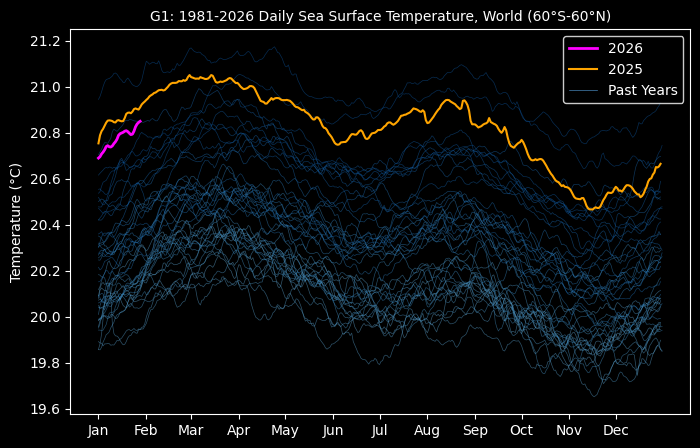

In [3]:
# グラフ描画
if __name__ == "__main__":
    draw_graph1(pivot_daily, 'World')

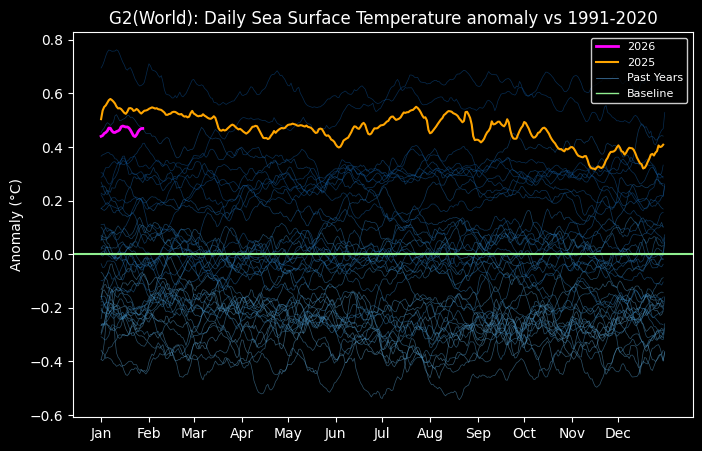

In [4]:
draw_graph2(pivot_daily_anom_monthly, 'World')       # Monthly Offset

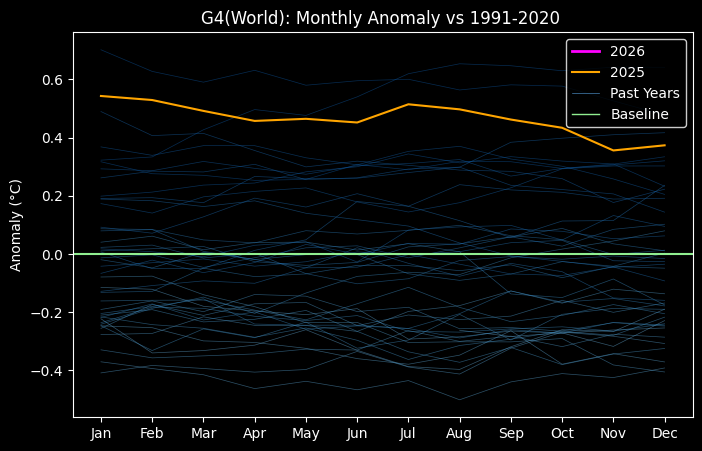

In [5]:
draw_graph4(pivot_monthly_anom_monthly, 'World')     # Monthly Offsets

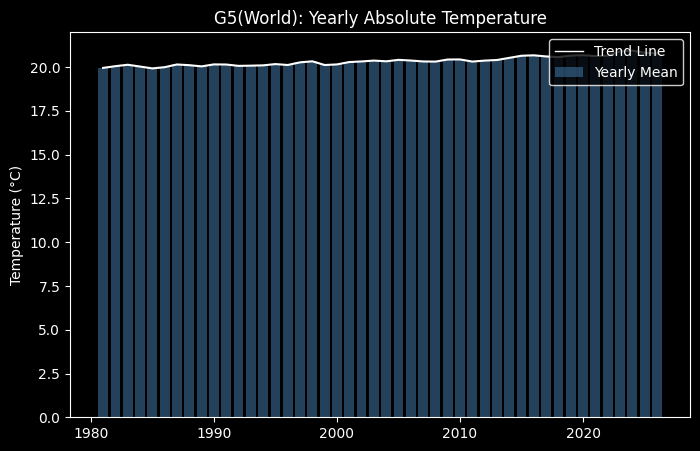

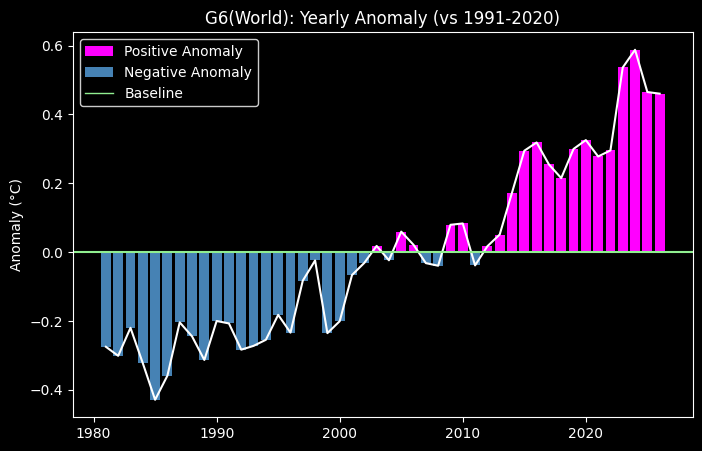

In [6]:
wrld_yearly = draw_yearly_graphs(df, global_mean, 'World')         # Yearly Fixed 0.88

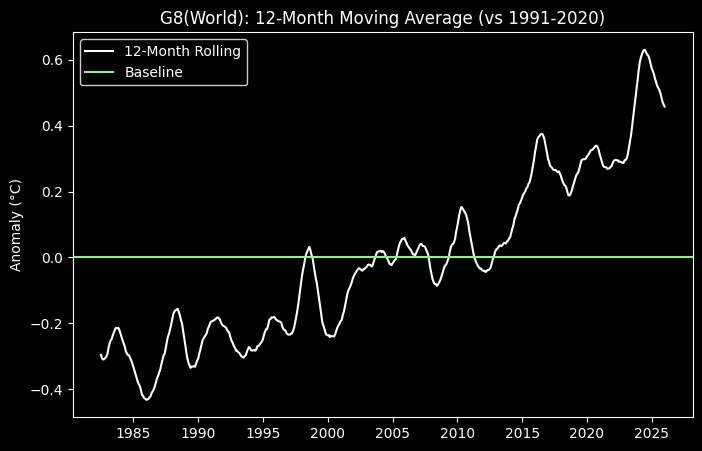

In [7]:
draw_graph8(df, 'World')                             # Monthly Offsets (Rolling)

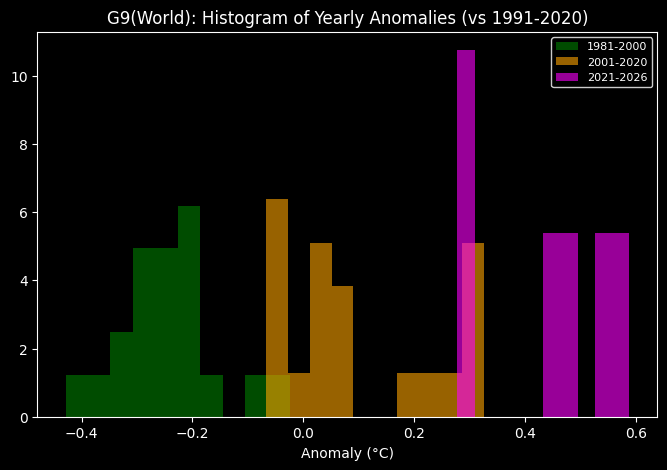

In [8]:
draw_graph9(df, 'World')                             # Yearly Fixed 0.88

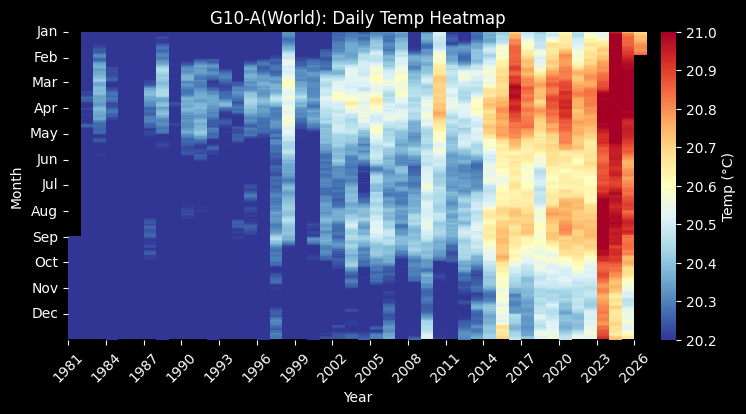

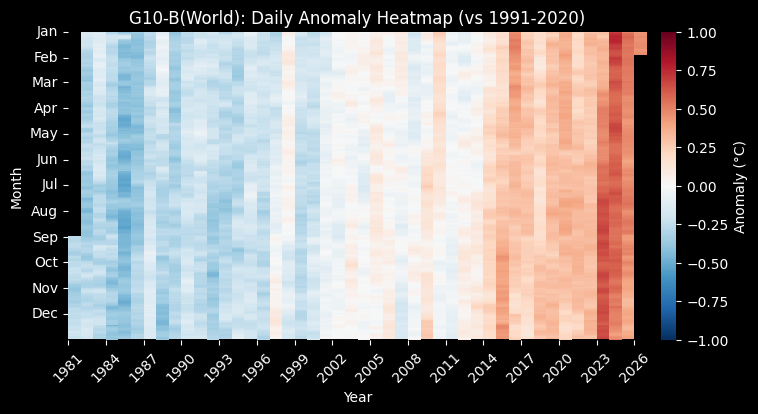

In [9]:
draw_graph10(pivot_daily, pivot_daily_anom_monthly, 'World') # Monthly Offset

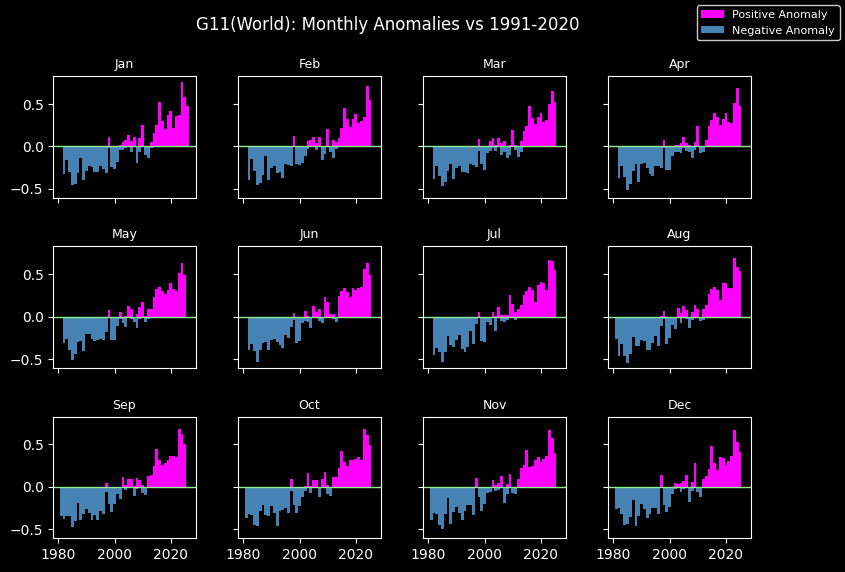

In [10]:
draw_graph11(df, 'World')                            # Monthly Offsets